# Week 8 — Model Explainability

`notebooks/06_model_selection.ipynb` ended with a decision: **Gaussian naive
Bayes**, 99.55% on 440 held-out rows, with a tuned random forest as the recorded
runner-up. This notebook asks the question that decision does not answer.

> A farmer is told to plant jute. Why?

"Because the model said so, and the model is 99.55% accurate" is not an answer.
It is not an answer to a regulator either, and it is no use at all when the model
is wrong — which, on this test set, it is twice.

Three tools, in increasing resolution:

* **§2 Permutation importance** — which measurements the model relies on,
  computed on data it never trained on. The trustworthy replacement for Week 7's
  `feature_importances_`.
* **§3 The correlation trap** — why `P` and `K` can both look unimportant while
  the pair is essential.
* **§4 SHAP** — per-row attributions, summarised across many rows.
* **§5-§7 One prediction, explained end to end** — including one of the two
  mistakes, and the fallback explainer that runs when SHAP is not installed.

The concepts are defined in
[`docs/curriculum/week08/learning_notes.md`](../docs/curriculum/week08/learning_notes.md);
this notebook applies them.

## 0. Setup

The same pattern as every week: repository root onto `sys.path`, logic imported
from `src/`. This week's module is `src/evaluation/explainability.py`
(`permutation_feature_importance`, `explain_prediction`), covered by
`tests/test_explainability.py`.

`EXPLAINER_BACKEND` reports which single-prediction explainer this environment
has: `"shap"` when the package imported, `"permutation"` for the documented
fallback. Every result below carries the same label, so no number here can be
quoted without knowing how it was produced.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

from src.data import DEFAULT_RANDOM_STATE, FEATURE_COLUMNS, TARGET_COLUMN
from src.evaluation import (
    EXPLAINER_BACKEND,
    SHAP_AVAILABLE,
    evaluate_model,
    explain_prediction,
    permutation_feature_importance,
)
from src.models import get_naive_bayes, get_random_forest
from src.preprocessing import build_preprocessor

pd.set_option("display.width", 120)

print("explainer backend :", EXPLAINER_BACKEND, "| shap importable:", SHAP_AVAILABLE)
print("seed              :", DEFAULT_RANDOM_STATE)

explainer backend : shap | shap importable: True
seed              : 42


In [2]:
FEATURES = list(FEATURE_COLUMNS)

train = pd.read_csv(REPO_ROOT / "data" / "processed" / "train.csv")
test = pd.read_csv(REPO_ROOT / "data" / "processed" / "test.csv")
X_train, y_train = train[FEATURES], train[TARGET_COLUMN]
X_test, y_test = test[FEATURES], test[TARGET_COLUMN]


def make_pipeline(model) -> Pipeline:
    """Week 3's preprocessor followed by a model, as one estimator."""
    return Pipeline([("preprocess", build_preprocessor()), ("model", model)])


# The two models Part 2 finished with: the chosen one, and its runner-up with
# the settings the grid search selected.
final_model = make_pipeline(get_naive_bayes()).fit(X_train, y_train)
tuned_forest = make_pipeline(get_random_forest(max_depth=10, n_estimators=100)).fit(
    X_train, y_train
)

print("final model  :", type(final_model.named_steps["model"]).__name__,
      f"- test accuracy {evaluate_model(final_model, X_test, y_test)['accuracy']:.4f}")
print("runner-up    :", type(tuned_forest.named_steps["model"]).__name__,
      f"- test accuracy {evaluate_model(tuned_forest, X_test, y_test)['accuracy']:.4f}")
print("explaining   :", len(X_test), "held-out rows the models never trained on")

final model  : GaussianNB - test accuracy 0.9955
runner-up    : RandomForestClassifier - test accuracy 0.9955
explaining   : 440 held-out rows the models never trained on


## 1. What was wrong with `feature_importances_`

Week 7 plotted the forest's built-in importances and then undermined them in the
same section. Three problems, all structural:

1. **Measured on the training data.** A feature the model overfitted on scores
   highly whether or not it helps on unseen rows.
2. **It describes bookkeeping, not reliance.** Mean decrease in impurity counts
   how much Gini each split removed. A feature can rack up impurity reduction in
   nodes that barely affect the final answer.
3. **Most models do not have it.** `GaussianNB` — the model this project
   actually chose — has no `feature_importances_` at all, so Week 7's tool
   cannot explain the deployed model even in principle.

Permutation importance fixes all three by asking a blunter question: *break one
column and see what it costs.*

```
score the fitted model on held-out rows          -> baseline
for each feature:
    shuffle that column (values kept, alignment destroyed)
    score again
    importance = baseline - shuffled score
repeat n_repeats times and average
```

Nothing is refitted, so the number describes **this** model's reliance on
**this** column, and because it is computed on rows the model never saw, it
measures generalisation rather than memorisation.

In [3]:
forest_test_importance = permutation_feature_importance(
    tuned_forest, X_test, y_test, n_repeats=10
)
forest_train_importance = permutation_feature_importance(
    tuned_forest, X_train, y_train, n_repeats=10
)
builtin = pd.Series(
    tuned_forest.named_steps["model"].feature_importances_, index=FEATURES, name="built-in (MDI)"
)

comparison = pd.DataFrame(
    {
        "built-in (MDI, train)": builtin,
        "permutation (train)": forest_train_importance["importance_mean"],
        "permutation (test)": forest_test_importance["importance_mean"],
    }
).sort_values("permutation (test)", ascending=False)

comparison.round(4)

,"built-in (MDI, train)",permutation (train),permutation (test)
humidity,0.2185,0.2930,0.3170
N,0.1044,0.2055,0.2020
rainfall,0.2164,0.1779,0.1689
K,0.1896,0.1459,0.1484
P,0.1457,0.0945,0.1114
temperature,0.0743,0.0032,0.0066
ph,0.0511,0.0039,0.0045


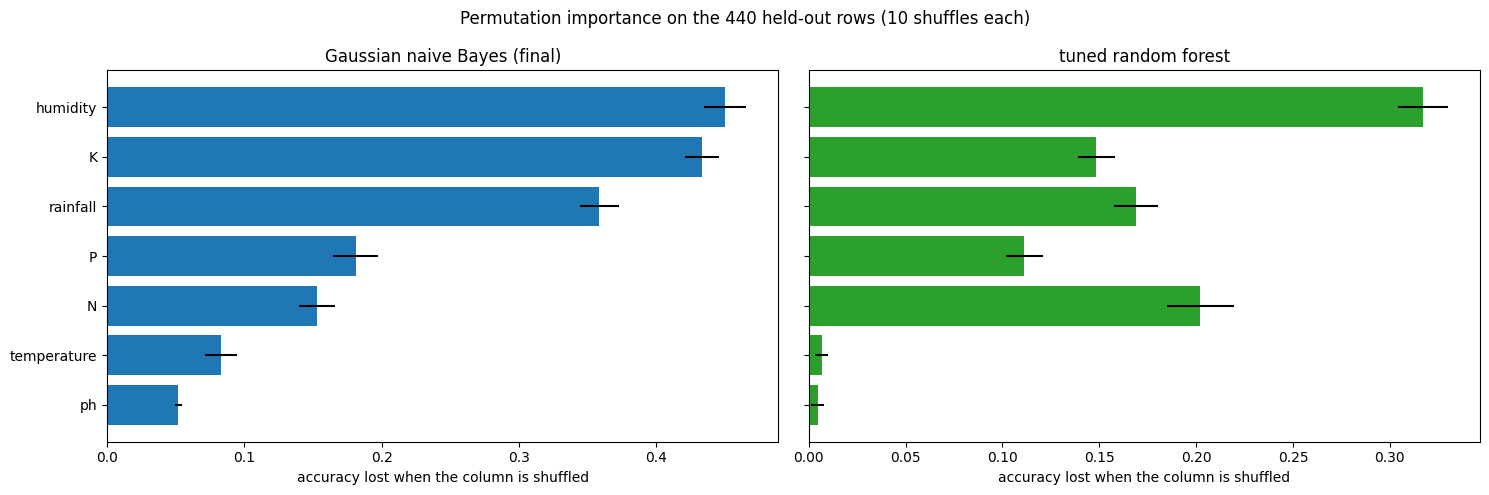

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for axis, (model, name) in zip(
    axes, [(final_model, "Gaussian naive Bayes (final)"), (tuned_forest, "tuned random forest")],
    strict=True,
):
    table = permutation_feature_importance(model, X_test, y_test, n_repeats=10).sort_values(
        "importance_mean"
    )
    axis.barh(
        table.index,
        table["importance_mean"],
        xerr=table["importance_std"],
        color="tab:blue" if "naive" in name else "tab:green",
    )
    axis.set_xlabel("accuracy lost when the column is shuffled")
    axis.set_title(name)

figure.suptitle("Permutation importance on the 440 held-out rows (10 shuffles each)")
figure.tight_layout()

### Reading it

**The two methods rank the forest's features differently**, and that
disagreement is the reason for computing the second one. MDI puts
`rainfall` (0.216) second and `N` (0.104) fifth; held-out permutation reverses
them — `N` costs 0.202 accuracy when shuffled and `rainfall` 0.169. Same fitted
forest, same seven columns, different question asked. They agree only at the
bottom: `temperature` (0.007) and `ph` (0.005) are worth almost nothing to this
model on unseen rows, where MDI still credited them with 0.074 and 0.051 — a
neat illustration of point 2 above, since those splits happened without helping.

Two properties worth naming:

* **The units mean something.** 0.317 for `humidity` means this forest loses
  **31.7 percentage points** of accuracy — from 99.5% down to about 68% — when
  that one column is scrambled. MDI's 0.219 is a share of impurity removed,
  which is not a quantity anyone can act on.
* **The error bars are visible.** Ten shuffles give a standard deviation per
  feature (±0.013 for `humidity`, ±0.003 for `ph`), and features whose bars
  overlap are not distinguishable. The forest's `temperature` and `ph` bars
  nearly touch zero, which is the honest way of saying "this model would barely
  notice if those two columns were deleted".

**The final model's numbers are larger than the forest's across the board** —
`humidity` 0.451 against 0.317, `K` 0.434 against 0.148, and even `ph` 0.052
against 0.005. Naive Bayes multiplies one density per feature per class, so
corrupting any single feature damages every class score; the forest can route
around a broken column using the other six, because each tree only ever saw 2 of
the 7 at a time. That difference is not "naive Bayes is worse" — it is
redundancy, and the forest having it is exactly what the ensemble was for.

Note also what has just happened: **the chosen model has been explained at all.**
`GaussianNB` has no `feature_importances_`; permutation importance works on it
because it only needs `predict`.

## 2. The correlation trap

Permutation importance has one well-known failure mode, and this dataset walks
straight into it. Week 2 measured a **0.74 correlation between `P` and `K`**.

Shuffle `P` alone and the model still has `K`, which carries much of the same
information — so `P` looks less important than it is. Shuffle `K` alone and the
same argument runs in reverse. Shuffle **both together** and the pair's real
contribution appears.

In [5]:
rng = np.random.default_rng(DEFAULT_RANDOM_STATE)
baseline = evaluate_model(final_model, X_test, y_test)["accuracy"]


def accuracy_with_shuffled(columns, repeats=10):
    """Mean accuracy after shuffling the given columns (jointly, if several)."""
    scores = []
    for _ in range(repeats):
        corrupted = X_test.copy()
        order = rng.permutation(len(corrupted))
        for column in columns:
            corrupted[column] = X_test[column].to_numpy()[order]
        scores.append(evaluate_model(final_model, corrupted, y_test)["accuracy"])
    return float(np.mean(scores))


rows = [
    {"shuffled": "nothing (baseline)", "accuracy": baseline, "cost": 0.0},
    *[
        {
            "shuffled": label,
            "accuracy": (score := accuracy_with_shuffled(columns)),
            "cost": baseline - score,
        }
        for label, columns in [
            ("P", ["P"]),
            ("K", ["K"]),
            ("P and K together", ["P", "K"]),
            ("temperature", ["temperature"]),
            ("ph", ["ph"]),
            ("temperature and ph", ["temperature", "ph"]),
        ]
    ],
]

pd.DataFrame(rows).set_index("shuffled").round(4)

,accuracy,cost
shuffled,,
nothing (baseline),0.9955,0.0000
P,0.8164,0.1791
K,0.5630,0.4325
P and K together,0.4302,0.5652
temperature,0.9105,0.0850
ph,0.9475,0.0480
temperature and ph,0.8502,0.1452


Shuffling `P` alone costs the final model **17.9 points** of accuracy and `K`
alone **43.3**; shuffling both together costs **56.5**, dropping the model to
43%. Each single number understates the pair, because whichever nutrient survives
the shuffle carries part of the other's information — that is what a 0.74
correlation buys. **Neither single number tells you what deleting the pair would
do**, and the general form of the lesson is: a low permutation importance means
"the model can manage without *this column alone*", never "this measurement does
not matter".

The control rows are the contrast. `temperature` (8.5 points) and `ph`
(4.8 points) are uncorrelated with each other, and shuffling them together costs
14.5 — near enough the sum of the two, and nothing like the nutrients' pattern.
No hidden partnership to reveal.

## 3. SHAP — attributing one prediction across its features

Permutation importance is still a statement about the model over a *set* of
rows. SHAP (SHapley Additive exPlanations) works one row at a time.

The idea comes from cooperative game theory. A prediction is a payout; the
features are players who produced it together. A feature's **Shapley value** is
its average marginal contribution over every possible order in which the features
could have been revealed — which is the unique attribution satisfying a short
list of fairness properties. The practical consequence:

```
base value (the model's average output) + sum of the feature contributions
    = the model's output for this row
```

That additivity is what permutation importance cannot offer. A SHAP explanation
is a complete account of one prediction, not a ranking.

The cost is compute: exact Shapley values need every subset of features.
`TreeExplainer` exploits tree structure to get them fast for forests;
`KernelExplainer` approximates them for any model at all, which is what the
chosen naive Bayes pipeline needs.

In [6]:
if SHAP_AVAILABLE:
    import shap

    print("shap version:", shap.__version__)

SAMPLE_ROWS = 60
sample = X_test.sample(SAMPLE_ROWS, random_state=DEFAULT_RANDOM_STATE).sort_index()
background = X_train.sample(100, random_state=DEFAULT_RANDOM_STATE)

# `TreeExplainer` explains the *forest*, not the pipeline wrapped around it, so
# it must be fed what the forest was actually fitted on: the standardised
# columns. Standardisation is a linear rescaling, so "high" and "low" still mean
# what they meant before, and the column names survive the trip.
scaled_sample = pd.DataFrame(
    tuned_forest.named_steps["preprocess"].transform(sample),
    columns=FEATURES,
    index=sample.index,
)

print("explaining", len(sample), "held-out rows")
print("background :", len(background), "training rows define 'an average field'")
print("tree input  :", scaled_sample.shape, "- the forest's own (standardised) view")

shap version: 0.46.0
explaining 60 held-out rows
background : 100 training rows define 'an average field'
tree input  : (60, 7) - the forest's own (standardised) view


shap values shape: (60, 7, 22) = (rows, features, crops)


/tmp/ipykernel_7782/1284950737.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


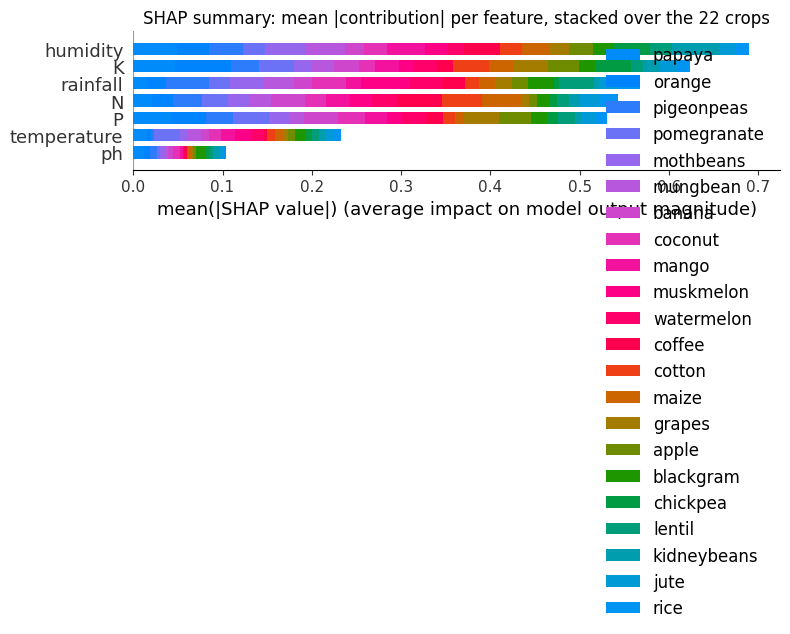

In [7]:
if SHAP_AVAILABLE:
    forest_values = shap.TreeExplainer(tuned_forest.named_steps["model"]).shap_values(scaled_sample)
    print("shap values shape:", forest_values.shape, "= (rows, features, crops)")

    per_class = [forest_values[:, :, k] for k in range(forest_values.shape[2])]
    shap.summary_plot(
        per_class,
        scaled_sample,
        class_names=list(tuned_forest.named_steps["model"].classes_),
        plot_type="bar",
        show=False,
    )
    plt.title("SHAP summary: mean |contribution| per feature, stacked over the 22 crops")
    plt.tight_layout()
else:
    print("SHAP is not installed; §4 falls back to per-sample permutation - see §7.")

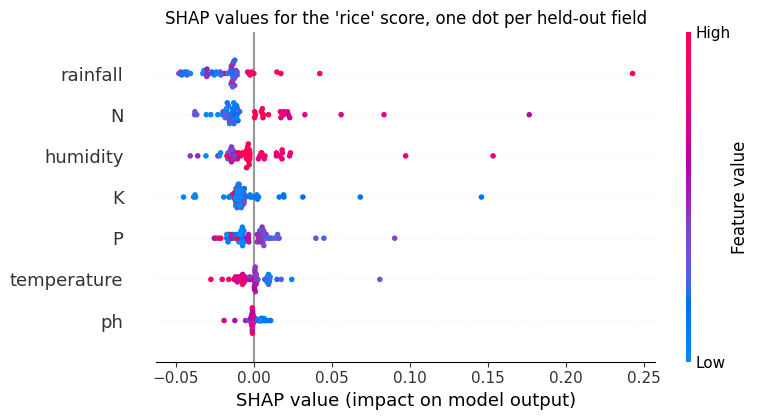

In [8]:
if SHAP_AVAILABLE:
    rice_index = list(tuned_forest.named_steps["model"].classes_).index("rice")
    shap.summary_plot(forest_values[:, :, rice_index], scaled_sample, show=False)
    plt.title("SHAP values for the 'rice' score, one dot per held-out field")
    plt.tight_layout()

### Reading the two SHAP plots

The **bar plot** is the whole-model view: for each feature, the average absolute
contribution it makes, stacked over the 22 crops. It is the same kind of claim as
permutation importance — a ranking — but built from per-row attributions rather
than from breaking columns, and it agrees with the permutation ranking on the
extremes (`humidity` high, `ph` negligible), which is the reassurance you want
when two independent methods are available.

The **beeswarm plot** is where SHAP earns its cost. Each dot is one held-out
field; its horizontal position is that field's contribution to the model's *rice*
score, and its colour is the feature's value (red high, blue low). Read the
`rainfall` row:

* dots far to the right, coloured red — **high rainfall pushes a field towards
  rice**;
* dots to the left, coloured blue — low rainfall pushes it away.

That is not a global fact about the model, it is 60 individual statements, and it
recovers the agronomy: rice wants water. `humidity` shows the same direction; the
`ph` row is a vertical smear at zero, meaning soil pH moved the rice score for
essentially nobody.

## 4. One prediction, explained end to end

Everything so far still averages over rows. Now take a single field —
**test row 378**, the one Part 2 identified as one of the two mistakes — and
account for its prediction completely.

`explain_prediction(model, X_row)` returns three things together, because none of
them is an explanation on its own: the prediction and its probability, the full
`predict_proba` breakdown (what the runners-up were), and the per-feature
contributions.

In [9]:
CONFIDENT_ROW = 0          # a routine, correct prediction
MISTAKE_ROW = 378          # true rice, predicted jute by both finalists

confident = explain_prediction(
    final_model, X_test.iloc[[CONFIDENT_ROW]], background=background
)

print("field       :", X_test.iloc[CONFIDENT_ROW].round(1).to_dict())
print("true crop   :", y_test.iloc[CONFIDENT_ROW])
print("prediction  :", confident["prediction"], f"at {confident['probability']:.4f}")
print("method      :", confident["method"])
print("\nrunners-up:")
print(confident["probabilities"].head(3).round(4).to_string())
print("\ncontributions (largest first):")
print(confident["contributions"].round(4).to_string())

  0%|          | 0/1 [00:00<?, ?it/s]

field       : {'N': 13.0, 'P': 23.0, 'K': 6.0, 'temperature': 24.0, 'humidity': 90.3, 'ph': 7.4, 'rainfall': 102.7}
true crop   : orange
prediction  : orange at 1.0000
method      : shap

runners-up:
orange        1.0
mothbeans     0.0
pigeonpeas    0.0

contributions (largest first):
K              0.3504
humidity       0.2254
rainfall       0.1953
P              0.1173
N              0.0582
ph             0.0039
temperature   -0.0005


In [10]:
mistake = explain_prediction(final_model, X_test.iloc[[MISTAKE_ROW]], background=background)

print("field       :", X_test.iloc[MISTAKE_ROW].round(2).to_dict())
print("true crop   :", y_test.iloc[MISTAKE_ROW])
print("prediction  :", mistake["prediction"], f"at {mistake['probability']:.4f}")
print("method      :", mistake["method"])
print("\nrunners-up:")
print(mistake["probabilities"].head(3).round(4).to_string())
print("\ncontributions (largest first):")
print(mistake["contributions"].round(4).to_string())

  0%|          | 0/1 [00:00<?, ?it/s]

field       : {'N': 67.0, 'P': 43.0, 'K': 39.0, 'temperature': 26.04, 'humidity': 84.97, 'ph': 6.0, 'rainfall': 186.75}
true crop   : rice
prediction  : jute at 0.8354
method      : shap

runners-up:
jute      0.8354
rice      0.1646
coffee    0.0000

contributions (largest first):
rainfall       0.3318
K              0.1217
N              0.1203
temperature    0.0980
P              0.0971
humidity       0.0240
ph            -0.0225


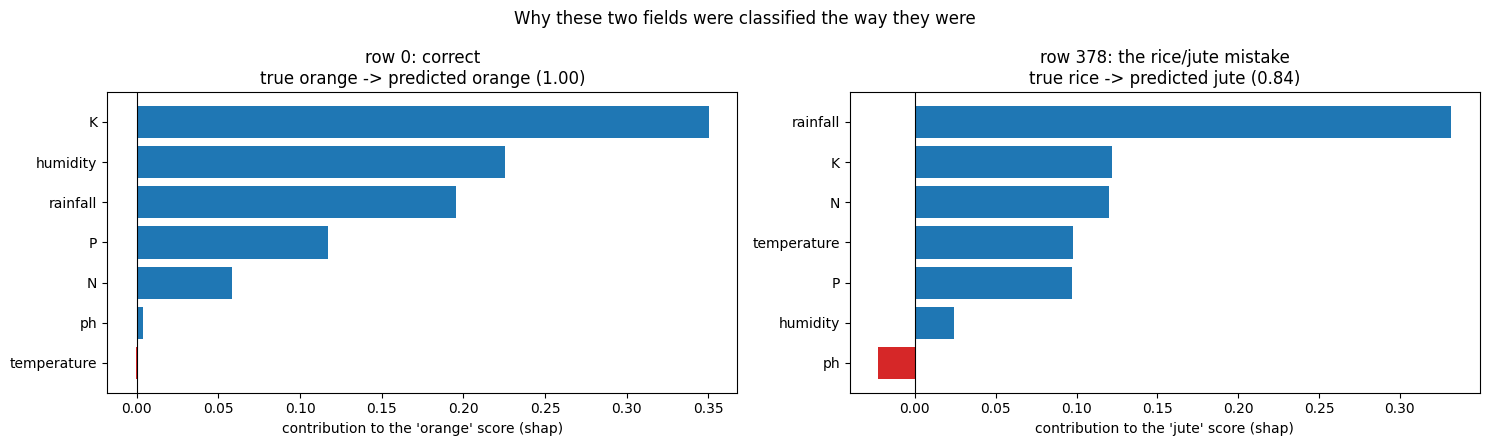

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for axis, (result, row_index, title) in zip(
    axes,
    [
        (confident, CONFIDENT_ROW, f"row {CONFIDENT_ROW}: correct"),
        (mistake, MISTAKE_ROW, f"row {MISTAKE_ROW}: the rice/jute mistake"),
    ],
    strict=True,
):
    contributions = result["contributions"].sort_values()
    axis.barh(
        contributions.index,
        contributions.to_numpy(),
        color=["tab:red" if value < 0 else "tab:blue" for value in contributions],
    )
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_xlabel(f"contribution to the '{result['prediction']}' score ({result['method']})")
    axis.set_title(
        f"{title}\ntrue {y_test.iloc[row_index]} -> predicted {result['prediction']}"
        f" ({result['probability']:.2f})"
    )

figure.suptitle("Why these two fields were classified the way they were")
figure.tight_layout()

In [12]:
# The measurements that drove the mistake, against what the two crops usually look like.
pair = train[train[TARGET_COLUMN].isin(["rice", "jute"])]
profile = pair.groupby(TARGET_COLUMN)[FEATURES].mean().round(1)
profile.loc["this field"] = X_test.iloc[MISTAKE_ROW].round(1)
profile

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
jute,78.1,47.1,39.9,24.9,79.1,6.7,175.8
rice,79.8,47.0,39.8,23.9,82.2,6.4,237.2
this field,67.0,43.0,39.0,26.0,85.0,6.0,186.8


### The explanation, in plain language

**Row 0 — a routine prediction.** The model returns **orange at probability
1.00**, with every other crop rounding to zero, and the contributions are led by
`K` (0.35), `humidity` (0.23) and `rainfall` (0.20). This field's potassium
reading of 6 is far below almost every other crop's range, so one measurement
alone is nearly conclusive and the rest merely agree with it. There is nothing to
argue with, which is what the overwhelming majority of predictions should look
like.

**Row 378 — the mistake, which is the interesting one.** Written out for the
person who has to act on it:

> The model recommended **jute** with 84% confidence, and put **rice** second at
> 16%. The measurement that decided it was **rainfall = 186.75 mm**. Fields of
> rice in the training data average **237 mm**; fields of jute average
> **176 mm**. On every other measurement the two crops are nearly identical —
> nitrogen 80 vs 78, phosphorus 47 vs 47, potassium 40 vs 40, humidity 82 vs 79 —
> so rainfall is carrying almost the whole decision, and this field's rainfall
> reads like jute's.
>
> The field really was rice. The model was not malfunctioning: it was reporting
> the most likely crop given a genuinely ambiguous reading, and it flagged its
> own doubt by leaving 16% on rice, far above the ~0% it gives the other twenty
> crops.

That is an explanation with three properties a stakeholder can use. It **names
the deciding measurement** rather than the model. It **quantifies the
alternative**, so "the model was unsure" is a number rather than a feeling. And
it **suggests an action**: any recommendation where the runner-up holds more
than, say, 15% could be sent to a human, which on this test set would have caught
both errors at the cost of reviewing a handful of predictions.

## 5. The fallback explainer, and which one was used

SHAP is an optional dependency, carrying the same risk as XGBoost in Week 7: it
compiles, and it does not install everywhere. `explain_prediction` therefore has
a fixed, documented fallback rather than an open-ended one:

1. **Per-sample permutation** — take the row, replace one feature at a time with
   values drawn from a background sample of training rows, and measure how far
   the predicted class's probability moves. Reported as
   `p(real value) - mean p(perturbed)`: positive when the measured value supports
   the prediction.
2. **The raw `predict_proba` breakdown** across all 22 crops for that row, which
   is what says whether the model was confident or breaking a tie.

The fallback's numbers are drops in predicted probability, **not** Shapley
values: they rank features for the row, but they do not add up to the output the
way SHAP's do, and they are systematically larger because a perturbation
typically destroys more of the prediction than a single feature's fair share of
it. Forcing it with `method="permutation"` runs it in any environment, which is
how the comparison below is possible.

In [13]:
fallback = explain_prediction(
    final_model, X_test.iloc[[MISTAKE_ROW]], background=background, method="permutation"
)

side_by_side = pd.DataFrame(
    {
        f"{mistake['method']} (used)": mistake["contributions"],
        "permutation fallback": fallback["contributions"],
    }
).sort_values("permutation fallback", ascending=False)

print("backend actually used for the explanation above:", mistake["method"])
print("fallback agrees on the decisive feature       :",
      fallback["top_feature"] == mistake["top_feature"],
      f"({fallback['top_feature']})")
side_by_side.round(4)

backend actually used for the explanation above: shap
fallback agrees on the decisive feature       : True (rainfall)


,shap (used),permutation fallback
rainfall,0.3318,0.6053
temperature,0.0980,0.2749
P,0.0971,0.2485
N,0.1203,0.2391
K,0.1217,0.1966
ph,-0.0225,0.0385
humidity,0.0240,-0.0050


### The two backends agree where it counts, and not everywhere

Both put **`rainfall`** first for this row by a wide margin, which is the part of
the explanation anyone would repeat out loud. Below that they diverge: the
fallback ranks `temperature` second where SHAP has it fourth, and the fallback's
numbers are about twice the size throughout.

Neither is a bug. Replacing this field's temperature with a random training value
often lands it in a season no crop in the jute/rice band grows in, which knocks
the probability down a long way — the fallback measures that. SHAP instead asks
what temperature contributed *on average over every order in which the features
could have been revealed*, and much of that credit ends up assigned to the
features temperature was standing in for. Use the fallback as a ranking of
"which measurement would hurt most if it were wrong", and SHAP as an additive
account of the prediction. Report which one produced the numbers — the
`"method"` key exists so that this is never a guess.

In [14]:
print("EXPLAINER USED IN THIS RUN :", EXPLAINER_BACKEND)
print("shap importable            :", SHAP_AVAILABLE)
print("single-prediction method   :", mistake["method"])
print("fallback available always  : yes (method='permutation')")

# Guard rails: the claims in the prose above must survive a re-run.
assert mistake["prediction"] == "jute" and y_test.iloc[MISTAKE_ROW] == "rice"
assert mistake["probabilities"].index[1] == "rice"           # the true crop is the runner-up
assert mistake["top_feature"] == fallback["top_feature"]     # both backends agree
assert set(mistake["contributions"].index) == set(FEATURES)  # every feature accounted for
assert forest_test_importance.index[0] == "humidity"         # the held-out ranking is stable
assert forest_test_importance.loc["ph", "importance_mean"] < 0.02
print("\nall guard rails passed")

EXPLAINER USED IN THIS RUN : shap
shap importable            : True
single-prediction method   : shap
fallback available always  : yes (method='permutation')

all guard rails passed


## 6. What Week 8 produced, and what it deliberately did not

**Produced**

* **Permutation importance on held-out rows** for both finalists, with error
  bars, ranked against the forest's built-in MDI — and computed for a model
  (`GaussianNB`) that has no built-in importances at all.
* **The correlation trap, measured**: `P` and `K` cost more shuffled together
  than either does alone, so a low individual importance never means "this
  measurement does not matter".
* **SHAP**, used here because it imported cleanly: a stacked bar summary over 22
  crops and a beeswarm for the rice score, showing direction as well as
  magnitude.
* **`explain_prediction()`** in `src/evaluation/explainability.py`, returning the
  prediction, the full probability breakdown and per-feature contributions, with
  the SHAP-or-permutation backend recorded in every result and covered by
  `tests/test_explainability.py`.
* **One prediction explained end to end in plain language** — the rice/jute
  mistake, traced to a single rainfall reading of 186.75 mm sitting between the
  two crops' profiles, with the model's own 16% doubt as the flag that would have
  caught it.

**Not produced, on purpose**

* **No causal claim.** Every number here describes the fitted model. "The model
  relies on rainfall" is not "rainfall causes rice", and no amount of SHAP turns
  one into the other.
* **No re-tuning.** The test set was opened once, in Part 2, after the decisions;
  nothing in this notebook feeds back into a model choice.
* **No saved artifact and no reusable pipeline.** `models/` is still empty, there
  is no `predict()` entry point outside a notebook, and nothing here is packaged
  for another program to import. Serialising the final model, wrapping it in a
  tested prediction interface and putting it behind an API is Week 9 onwards.